Loaded 32,849 rows × 29 columns
Plotting 26 variables in a 7×4 grid


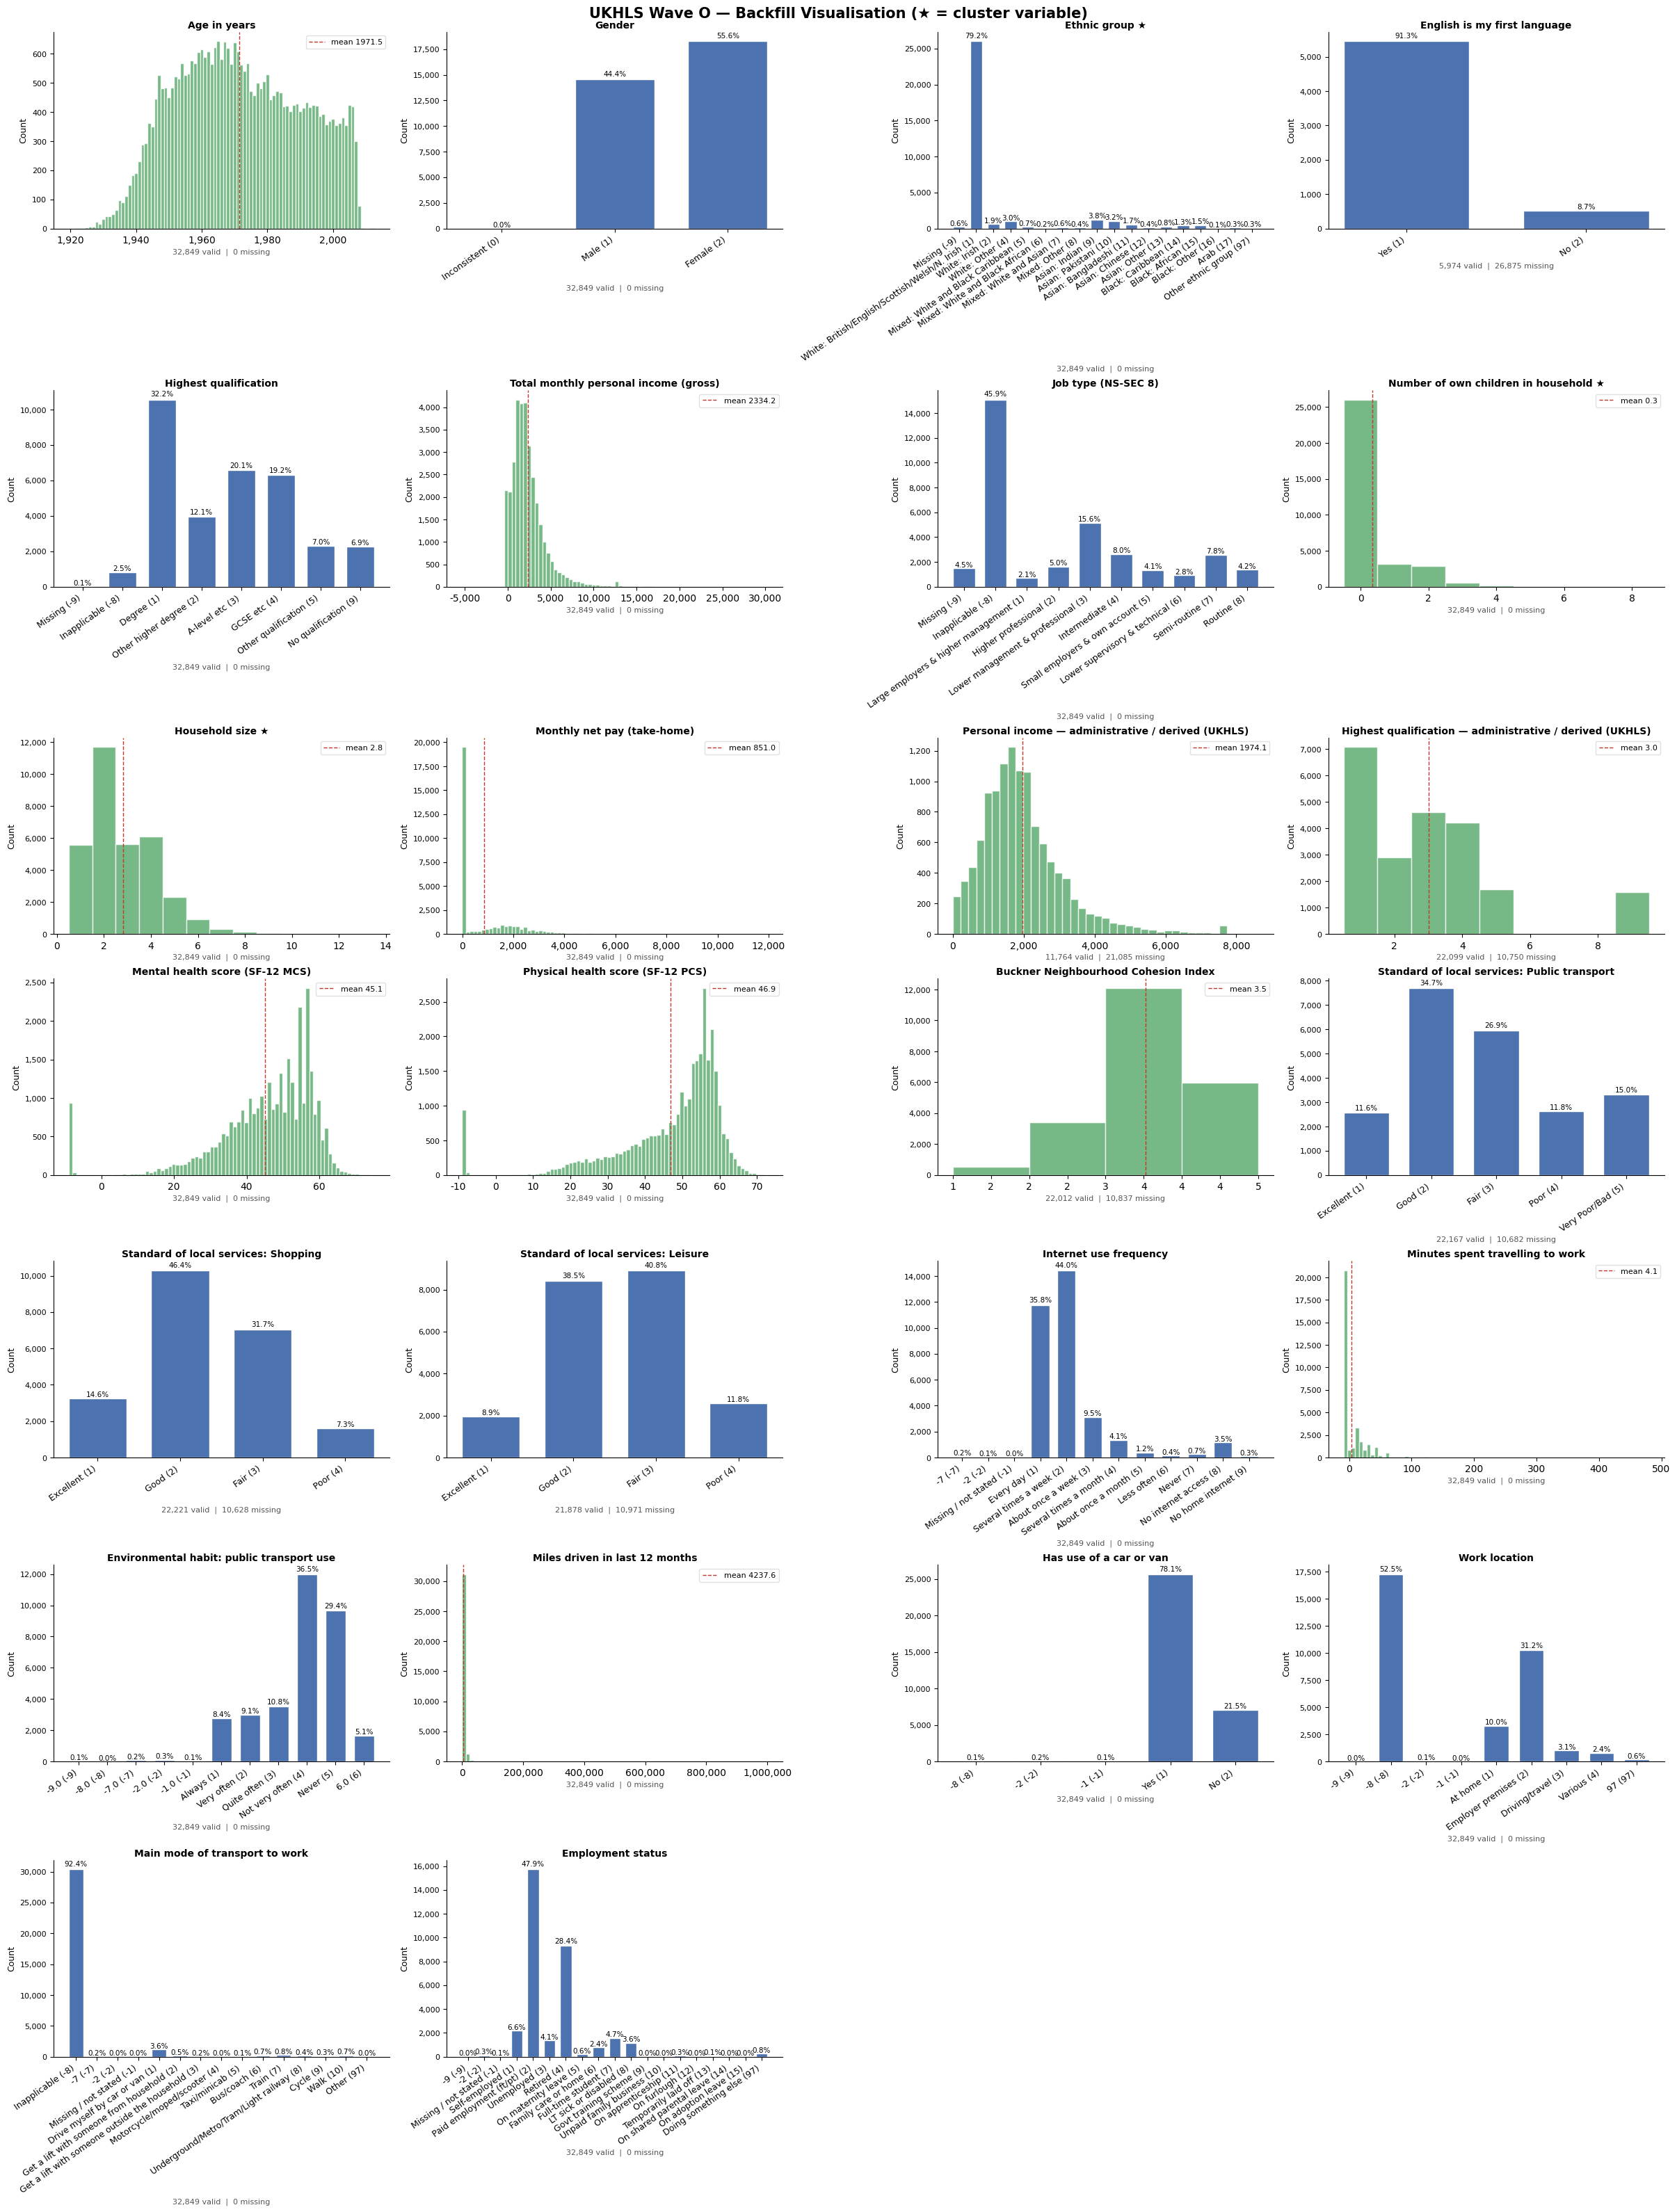

Saved to ../data/3_backfill_ukhls_waves/backfill_visualisation.png


In [1]:
# Variable Distribution Viewer
# Loads o_indresp_backfilled.pkl and plots every variable using
# human-readable labels and category names from config_variables.py

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import importlib
import data_pipeline.config_variables as _ukhls_vars
importlib.reload(_ukhls_vars)  # pick up any edits made since kernel started

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

VARIABLES        = _ukhls_vars.VARIABLES
CATEGORICAL_VARS = _ukhls_vars.CATEGORICAL_VARS
CONTINUOUS_VARS  = _ukhls_vars.CONTINUOUS_VARS

# ── Config ────────────────────────────────────────────────────────────────────
WAVE          = "o"
PICKLE_PATH   = "../data/3_backfill_ukhls_waves/o_indresp_backfilled.pkl"
COLS_PER_ROW  = 4
BAR_COLOR     = "#4C72B0"
MISSING_COLOR = "#d9534f"
HIST_COLOR    = "#55A868"
CLIP_COLOR    = "#e67e22"   # annotation colour for clip/floor markers

# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_pickle(PICKLE_PATH)
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")

# ── Build the ordered plot list ───────────────────────────────────────────────
plot_specs = []
for base_code, var_def in VARIABLES.items():
    if base_code == "pidp":
        continue

    col = f"{WAVE}_{base_code}"
    if col not in df.columns:
        continue

    plot_specs.append(dict(
        col          = col,
        label        = var_def["label"],
        is_cat       = var_def["categorical"],
        categories   = var_def["categories"],
        is_cluster   = var_def["cluster"],
        clip         = var_def.get("clip"),       # upper bound or None
        floor        = var_def.get("floor"),      # lower bound or None
        bin_width    = var_def.get("bin_width"),  # fixed histogram bin width or None
    ))

n_plots = len(plot_specs)
n_cols  = COLS_PER_ROW
n_rows  = (n_plots + n_cols - 1) // n_cols

print(f"Plotting {n_plots} variables in a {n_rows}×{n_cols} grid")

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 4.5 * n_rows),
    constrained_layout=True,
    )
axes_flat = axes.flatten()

for idx, spec in enumerate(plot_specs):
    ax   = axes_flat[idx]
    col  = spec["col"]
    # Always work with a plain numeric series to avoid Categorical setitem errors
    data = pd.to_numeric(df[col], errors="coerce")

    flag      = " ★" if spec["is_cluster"] else ""
    title     = spec["label"] + flag
    n_valid   = data.notna().sum()
    n_missing = data.isna().sum()
    subtitle  = f"{n_valid:,} valid  |  {n_missing:,} missing"

    # ── Categorical: bar chart (skipped when bin_width is set) ────────────
    if (spec["is_cat"] and not spec["bin_width"]) or (data.nunique(dropna=True) <= 12 and spec["categories"] is not None):

        cat_map = spec["categories"] or {}

        raw     = data.value_counts(dropna=True).sort_index()
        labels_x, counts_y, colors = [], [], []
        for rv, cnt in raw.items():
            lbl = cat_map.get(float(rv), str(rv))
            code_int = int(rv) if float(rv) == int(rv) else rv
            labels_x.append(f"{lbl} ({code_int})")
            colors.append(BAR_COLOR)
            counts_y.append(cnt)
        bars  = ax.bar(range(len(labels_x)), counts_y, color=colors, edgecolor="white", width=0.7)
        total = sum(counts_y)
        ax.set_xticks(range(len(labels_x)))
        ax.set_xticklabels(labels_x, rotation=35, ha="right", fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        for bar, cnt in zip(bars, counts_y):
            pct = 100 * cnt / total if total else 0
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                    f"{pct:.1f}%", ha="center", va="bottom", fontsize=7.5)
        ax.set_ylabel("Count", fontsize=9)
    else:
        vals = pd.to_numeric(data, errors="coerce").dropna()
        if len(vals) == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_ylabel("Count", fontsize=9)
        else:
            val_min, val_max = vals.min(), vals.max()
            bin_width = spec["bin_width"]
            if bin_width is not None:
                bins = np.arange(val_min, val_max + bin_width, bin_width)
            elif ((vals % 1) == 0).all() and val_max - val_min <= 120:
                bins = np.arange(val_min - 0.5, val_max + 1.5, 1)
            else:
                bins = min(80, max(20, len(vals) // 300))
            ax.hist(vals, bins=bins, color=HIST_COLOR, edgecolor="white", alpha=0.8)
            ax.axvline(vals.mean(), color="#c0392b", linestyle="--", linewidth=1,
                       label=f"mean {vals.mean():.1f}")
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
            ax.legend(fontsize=8, framealpha=0.6)
            ax.set_ylabel("Count", fontsize=9)

    ax.set_title(title, fontsize=10, fontweight="bold", pad=4)
    ax.set_xlabel(subtitle, fontsize=8, labelpad=3, color="#555")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

for unused_ax in axes_flat[n_plots:]:
    unused_ax.set_visible(False)

fig.suptitle(
    f"UKHLS Wave {WAVE.upper()} — Backfill Visualisation (★ = cluster variable)",
    fontsize=15, fontweight="bold", y=1.005,
    )
plt.savefig("../data/3_backfill_ukhls_waves/backfill_visualisation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to ../data/3_backfill_ukhls_waves/backfill_visualisation.png")